# LeetCode #129: Sum Root to Leaf Numbers

https://leetcode.com/problems/sum-root-to-leaf-numbers/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Collect all paths, parse as strings | O(n) | O(n·h) | Extra path storage per leaf |
| **DFS with running number** | **O(n)** | **O(h)** | **Optimal — accumulate in-place** |

## Understanding the Method

At each node, maintain a running number: `currentNum = parentNum * 10 + node.val`.
When reaching a leaf, add `currentNum` to the total.
Recursively sum the left and right subtrees' contributions.

## Constraints

- Number of nodes: `[1, 1000]`
- `0 <= Node.val <= 9`
- Tree depth does not exceed 10.

## Solutions

### C#

In [ ]:
public class Solution {
    public int SumNumbers(TreeNode root) => Dfs(root, 0);
    int Dfs(TreeNode node, int cur) {
        if (node == null) return 0;
        cur = cur * 10 + node.val;
        if (node.left == null && node.right == null) return cur;
        return Dfs(node.left, cur) + Dfs(node.right, cur);
    }
}

### Python

In [ ]:
class Solution:
    def sumNumbers(self, root) -> int:
        def dfs(node, cur):
            if not node:
                return 0
            cur = cur * 10 + node.val
            if not node.left and not node.right:
                return cur
            return dfs(node.left, cur) + dfs(node.right, cur)
        return dfs(root, 0)

### Go

In [ ]:
func sumNumbers(root *TreeNode) int {
    var dfs func(*TreeNode, int) int
    dfs = func(node *TreeNode, cur int) int {
        if node == nil { return 0 }
        cur = cur*10 + node.Val
        if node.Left == nil && node.Right == nil { return cur }
        return dfs(node.Left, cur) + dfs(node.Right, cur)
    }
    return dfs(root, 0)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn sum_numbers(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        fn dfs(node: &Option<Rc<RefCell<TreeNode>>>, cur: i32) -> i32 {
            if let Some(n) = node {
                let n = n.borrow();
                let cur = cur * 10 + n.val;
                if n.left.is_none() && n.right.is_none() { return cur; }
                dfs(&n.left, cur) + dfs(&n.right, cur)
            } else {
                0
            }
        }
        dfs(&root, 0)
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `root = [1, 2, 3]`  
Two paths: $1 \to 2$ forms 12, $1 \to 3$ forms 13. DFS accumulates $\text{cur} = \text{parent} \times 10 + \text{node.val}$ at each step, returning $\text{cur}$ at leaves.  
WHY tricky: Validates the core formula and confirms leaf detection when both children are null.  
$12 + 13 = 25$  
**Output:** `25`

### 2. Slightly Complex
**Input:** `root = [4, 9, 0, 5, 1]`  
Three paths: $4 \to 9 \to 5 = 495$, $4 \to 9 \to 1 = 491$, $4 \to 0 = 40$. The zero node is a leaf, so the path '40' includes a meaningful trailing zero that must not be dropped.  
WHY tricky: Tests $\text{cur} = 4 \times 10 + 0 = 40$ — the trailing zero is significant in the numeric representation.  
$495 + 491 + 40 = 1026$  
**Output:** `1026`

### 3. Edge Case: Time Factor
**Input:** Complete binary tree, $n = 1000$ nodes, all values $= 9$  
DFS visits all 1000 nodes once in $O(n)$. With $\sim500$ leaves each of depth $h = \lfloor \log_2(1000) \rfloor = 9$, each path forms a 10-digit number $9{,}999{,}999{,}999$.  
WHY tricky: Total sum $\approx 500 \times 10^{10} \approx 5 \times 10^{12}$, exceeding 32-bit int max ($2^{31}-1 \approx 2.1 \times 10^9$). Must use 64-bit integers.  
**Output:** $\sim 5 \times 10^{12}$ — requires 64-bit integer

### 4. Edge Case: Space Factor
**Input:** Left-skewed chain of depth 1000 (each node has only a left child)  
Recursion stack reaches $O(h) = O(1000)$. Only one leaf exists at the bottom, producing a single 1000-digit number that far exceeds all fixed-width integer types.  
WHY tricky: Stack depth is $O(n)$ worst case. The 1000-digit accumulated number overflows every primitive type. Iterative approach or tail-call optimization needed.  
**Output:** One enormous number — tests overflow and stack depth

### 5. Almost-Impossible but Plausible
**Input:** `root = [0, 0, 0, 0, 0, 0, 0]` (complete tree, 7 nodes, all zeros)  
Every root-to-leaf path is $0 \to 0 \to 0$, forming $0 \times 100 + 0 \times 10 + 0 = 0$. Four leaves each contribute 0. The algorithm must not skip zero-valued nodes or short-circuit on a zero accumulator.  
WHY tricky: Constraint allows $0 \le \text{Node.val} \le 9$. All-zero tree verifies the algorithm handles zero nodes without special-casing.  
$0 + 0 + 0 + 0 = 0$  
**Output:** `0`

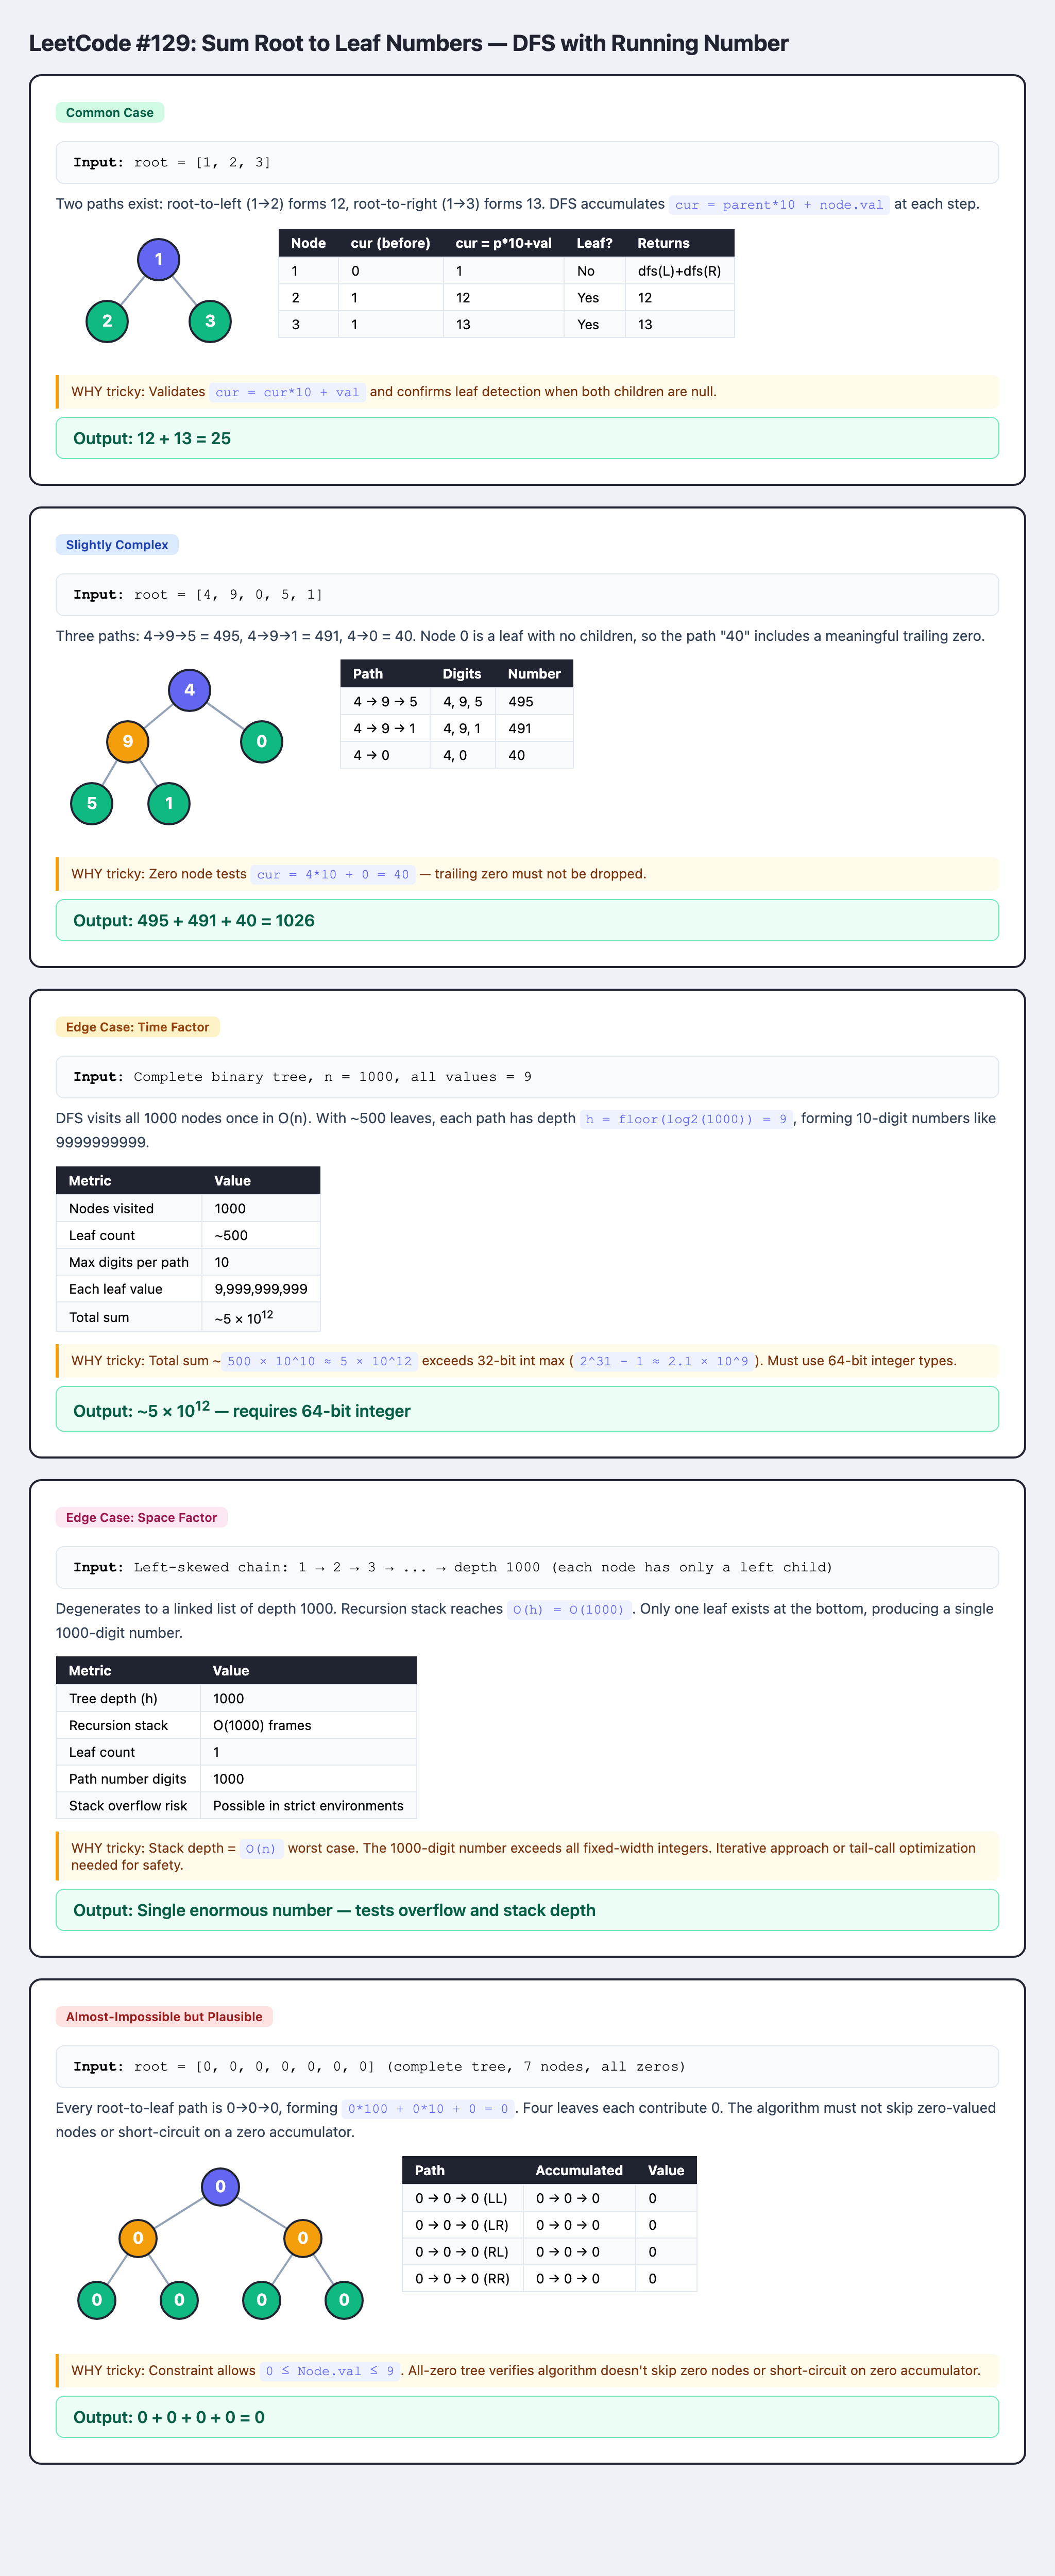